# Jereme Carne Notebook
# Applied Analytics (EDA)

- Author: [Jereme Carne](https://github.com/j-carne/)
- Repository: [datafun-06-applied](https://github.com/j-carne/datafun-06-applied/)
- Purpose: Apply the EDA workflow to a new dataset - Dynon avionics flight data
- Date: 2026-06

## Dataset Information

- Dataset: Dynon EFB flight data recording
- Grouped by altitude band (Below 2000 ft, 2000-4000 ft, 4000-6000 ft, Above 6000 ft)
- Source: Personal aircraft flight data export (kept local, not pushed to GitHub)


## Section 1. Project Setup and Imports

All imports and configuration appear once, at the top of the notebook.

In [1]:
# === Section 1a. DECLARE IMPORTS (BRING IN FREE CODE) ===

import logging
from typing import Any, Final

from datafun_toolkit.logger import get_logger, log_header
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("P06-DYNON", level="DEBUG")
log_header(LOG, "P06-DYNON")

# === Section 1c. Global Constants and Configuration ===

# CUSTOM: Data set name
DATASET_NAME: Final[str] = "dynon_data"

# CUSTOM: Grouping column (chose one categorical/non-numeric variable)

GROUP_COL: Final[str] = "altitude_band"

# CUSTOM: Numeric columns to analyze

SELECTED_NUMERIC_COLS: Final[list[str]] = [
    "pressure_altitude",
    "indicated_airspeed",
    "vertical_speed",
    "oat",
    "rpm_l",
]

# CUSTOM: Choose one numeric column for a manual statistics example.

EXAMPLE_NUMERIC_COL: Final[str] = "indicated_airspeed"

# CUSTOM: Choose a few numeric columns to check for correlations and plot.

SCATTER_X_COL: Final[str] = "pressure_altitude"
SCATTER_Y_COL: Final[str] = "indicated_airspeed"

BOX_Y_COL: Final[str] = "indicated_airspeed"

# CUSTOM: Assign readable labels for the charted variables.

SCATTER_X_LABEL: Final[str] = "Pressure Altitude (ft)"
SCATTER_Y_LABEL: Final[str] = "Indicated Airspeed (knots)"

BOX_Y_LABEL: Final[str] = "Indicated Airspeed (knots)"

# === Section 1d. Pandas Configuration for Display ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

LOG.info("Imports complete.")

2026-06-20 16:42:36 | INFO | P06-DYNON | === RUN START ===
2026-06-20 16:42:36 | INFO | P06-DYNON | project=P06-DYNON
2026-06-20 16:42:36 | INFO | P06-DYNON | repo_dir=datafun-06-applied
2026-06-20 16:42:36 | INFO | P06-DYNON | python=3.14.5
2026-06-20 16:42:36 | INFO | P06-DYNON | os=Windows 11
2026-06-20 16:42:36 | INFO | P06-DYNON | shell=powershell
2026-06-20 16:42:36 | INFO | P06-DYNON | cwd=notebooks
2026-06-20 16:42:36 | INFO | P06-DYNON | github_actions=False
2026-06-20 16:42:36 | INFO | P06-DYNON | Imports complete.


## Section 2. Load the Data

Before analysis, load the data to confirm it loads successfully and the structure matches expectations.

In [2]:
import os

# Move up one level so paths match the project root
os.chdir("..")
print(os.getcwd())

c:\Repos\datafun-06-applied


In [3]:
# Load Dynon flight data CSV into a DataFrame
LOG.info(f"Loading dataset: {DATASET_NAME}")
df_raw: pd.DataFrame = pd.read_csv(f"data/raw/{DATASET_NAME}.csv", low_memory=False)

# Select and rename only the columns needed for this EDA
df: pd.DataFrame = df_raw[
    [
        "Pressure Altitude (ft)",
        "Indicated Airspeed (knots)",
        "Vertical Speed (ft/min)",
        "OAT (deg C)",
        "RPM L",
    ]
].copy()
df.columns = [
    "pressure_altitude",
    "indicated_airspeed",
    "vertical_speed",
    "oat",
    "rpm_l",
]


# Create the altitude band grouping column
def classify_altitude(alt: float) -> str:
    if alt < 2000:
        return "Below 2000 ft"
    elif alt < 4000:
        return "2000-4000 ft"
    elif alt < 6000:
        return "4000-6000 ft"
    else:
        return "Above 6000 ft"


df["altitude_band"] = df["pressure_altitude"].apply(classify_altitude)

count_of_rows: int = df.shape[0]
count_of_columns: int = df.shape[1]
LOG.info(f"Loaded: {count_of_rows} rows, {count_of_columns} columns")

2026-06-20 16:42:36 | INFO | P06-DYNON | Loading dataset: dynon_data
2026-06-20 16:42:36 | INFO | P06-DYNON | Loaded: 14131 rows, 6 columns


## Section 3. Inspect Data Shape and Structure

Always start by understanding what columns exist, what types they are, and how large the dataset is.

In [4]:
# Preview the first few rows
LOG.info("Previewing first few rows of the dataset")
display(df.head())

2026-06-20 16:42:36 | INFO | P06-DYNON | Previewing first few rows of the dataset


,pressure_altitude,indicated_airspeed,vertical_speed,oat,rpm_l,altitude_band
0,4175.0,0.0,0.0,12.0,0.0,4000-6000 ft
1,4175.0,0.0,5.0,12.0,0.0,4000-6000 ft
2,4175.0,0.0,20.0,12.0,0.0,4000-6000 ft
3,4175.0,0.0,14.0,12.0,0.0,4000-6000 ft
4,4175.0,0.0,1.0,12.0,0.0,4000-6000 ft


In [5]:
LOG.info("Column names")
column_names: list[str] = list(df.columns)
print(column_names)

2026-06-20 16:42:36 | INFO | P06-DYNON | Column names


['pressure_altitude', 'indicated_airspeed', 'vertical_speed', 'oat', 'rpm_l', 'altitude_band']


## Section 4. Create Data Dictionary and Check Data Quality

A data dictionary helps with understanding the structure and quality of the data.

In [6]:
LOG.info("Building starter data dictionary")

data_dictionary = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
    }
)

LOG.debug(f"\n{data_dictionary}")

2026-06-20 16:42:36 | INFO | P06-DYNON | Building starter data dictionary
2026-06-20 16:42:36 | DEBUG | P06-DYNON | 
               column    dtype  missing_count  missing_pct
0   pressure_altitude  float64              6         0.04
1  indicated_airspeed  float64              6         0.04
2      vertical_speed  float64              6         0.04
3                 oat  float64              4         0.03
4               rpm_l  float64              9         0.06
5       altitude_band      str              0         0.00


In [7]:
LOG.info("Missing values per column:")
LOG.info(df.isnull().sum())

LOG.info("Checking missing values per column")
LOG.debug(f"\n{df.isna().sum().sort_values(ascending=False)}")

dup_count = int(df.duplicated().sum())
LOG.info(f"Duplicate rows detected: {dup_count}")

LOG.info("Call describe() for numeric columns")
LOG.debug(f"\n{df[SELECTED_NUMERIC_COLS].describe()}\n")

2026-06-20 16:42:36 | INFO | P06-DYNON | Missing values per column:
2026-06-20 16:42:36 | INFO | P06-DYNON | pressure_altitude     6
indicated_airspeed    6
vertical_speed        6
oat                   4
rpm_l                 9
altitude_band         0
dtype: int64
2026-06-20 16:42:36 | INFO | P06-DYNON | Checking missing values per column
2026-06-20 16:42:36 | DEBUG | P06-DYNON | 
rpm_l                 9
pressure_altitude     6
indicated_airspeed    6
vertical_speed        6
oat                   4
altitude_band         0
dtype: int64
2026-06-20 16:42:36 | INFO | P06-DYNON | Duplicate rows detected: 174
2026-06-20 16:42:36 | INFO | P06-DYNON | Call describe() for numeric columns
2026-06-20 16:42:36 | DEBUG | P06-DYNON | 
       pressure_altitude  indicated_airspeed  vertical_speed           oat         rpm_l
count       14125.000000        14125.000000    14125.000000  14127.000000  14122.000000
mean         5143.793628           86.116191       -0.801912     14.915835   1945.833522
s

## Section 5. Create Clean View for EDA

Keep the original DataFrame unchanged and drop rows missing key numeric fields and the grouping field.

In [8]:
cols_required: list[str] = SELECTED_NUMERIC_COLS + [GROUP_COL]
LOG.debug(f"Columns required to be non-missing: {cols_required}")

df_clean: pd.DataFrame = df.dropna(subset=cols_required).copy()

count_original: int = df.shape[0]
count_clean: int = df_clean.shape[0]
count_dropped: int = count_original - count_clean

print(f"Original rows: {count_original}")
print(f"Clean rows:    {count_clean}")
print(f"Rows dropped:  {count_dropped}")

LOG.info(f"Original rows: {count_original}")
LOG.info(f"Clean rows:    {count_clean}")
LOG.info(f"Rows dropped:  {count_dropped}")

2026-06-20 16:42:36 | DEBUG | P06-DYNON | Columns required to be non-missing: ['pressure_altitude', 'indicated_airspeed', 'vertical_speed', 'oat', 'rpm_l', 'altitude_band']
2026-06-20 16:42:36 | INFO | P06-DYNON | Original rows: 14131
2026-06-20 16:42:36 | INFO | P06-DYNON | Clean rows:    14122
2026-06-20 16:42:36 | INFO | P06-DYNON | Rows dropped:  9


Original rows: 14131
Clean rows:    14122
Rows dropped:  9


## Section 6. Descriptive Statistics for Numeric Columns

Summary statistics offer a quick overview: central tendency, spread, and distribution shape.
Grouping by altitude band enables comparing statistics across categories.

In [9]:
LOG.info("--------------- Manual statistics ---------------")

example_values = df_clean[EXAMPLE_NUMERIC_COL]

mean_value = np.mean(example_values)
std_value = np.std(example_values)
min_value = np.min(example_values)
max_value = np.max(example_values)
range_value = np.ptp(example_values)

LOG.debug(f"{EXAMPLE_NUMERIC_COL} Statistics (using numpy):")
LOG.debug(f"  Mean: {mean_value:.2f}")
LOG.debug(f"  Std Dev: {std_value:.2f}")
LOG.debug(f"  Min: {min_value:.2f}")
LOG.debug(f"  Max: {max_value:.2f}")
LOG.debug(f"  Range: {range_value:.2f}")

2026-06-20 16:42:36 | INFO | P06-DYNON | --------------- Manual statistics ---------------
2026-06-20 16:42:36 | DEBUG | P06-DYNON | indicated_airspeed Statistics (using numpy):
2026-06-20 16:42:36 | DEBUG | P06-DYNON |   Mean: 86.13
2026-06-20 16:42:36 | DEBUG | P06-DYNON |   Std Dev: 51.85
2026-06-20 16:42:36 | DEBUG | P06-DYNON |   Min: 0.00
2026-06-20 16:42:36 | DEBUG | P06-DYNON |   Max: 165.80
2026-06-20 16:42:36 | DEBUG | P06-DYNON |   Range: 165.80


In [10]:
LOG.info("Computing overall descriptive statistics")

stats_overall = df_clean[SELECTED_NUMERIC_COLS].describe().T
LOG.debug(f"\n{stats_overall}")

LOG.info("--------------- Using pandas groupby() and agg() ---------------")

LOG.info("Computing descriptive statistics by group")

df_numeric_subset: pd.DataFrame = df_clean[SELECTED_NUMERIC_COLS]
grouped = df_numeric_subset.groupby(df_clean[GROUP_COL])
df_stats_by_group: pd.DataFrame = grouped.agg(["count", "mean", "std", "min", "max"])

LOG.debug(f"\n{df_stats_by_group}")

2026-06-20 16:42:36 | INFO | P06-DYNON | Computing overall descriptive statistics
2026-06-20 16:42:36 | DEBUG | P06-DYNON | 
                      count         mean          std     min       25%     50%     75%     max
pressure_altitude   14122.0  5144.005311  1064.593063  3967.0  4163.250  4851.0  5994.0  7454.0
indicated_airspeed  14122.0    86.134485    51.852655     0.0    37.775    94.0   133.1   165.8
vertical_speed      14122.0    -0.796063   572.909404 -6426.0  -205.000    -7.0   110.0  5366.0
oat                 14122.0    14.916796     5.472719     7.0    10.000    13.0    21.0    23.0
rpm_l               14122.0  1945.833522   722.247200     0.0  1518.000  2401.5  2453.0  2742.0
2026-06-20 16:42:36 | INFO | P06-DYNON | --------------- Using pandas groupby() and agg() ---------------
2026-06-20 16:42:36 | INFO | P06-DYNON | Computing descriptive statistics by group
2026-06-20 16:42:36 | DEBUG | P06-DYNON | 
              pressure_altitude                                    

In [11]:
LOG.info("--------------- Improving the output ---------------")

stats_by_group_stacked: pd.DataFrame | pd.Series[Any] = df_stats_by_group.stack(level=0)
LOG.debug(f"\n{stats_by_group_stacked}")

2026-06-20 16:42:36 | INFO | P06-DYNON | --------------- Improving the output ---------------
2026-06-20 16:42:36 | DEBUG | P06-DYNON | 
                                  count         mean         std     min     max
altitude_band                                                                   
2000-4000 ft  pressure_altitude    1025  3978.542439    8.866435  3967.0  3999.0
              indicated_airspeed   1025     9.422829   20.091509     0.0    96.7
              vertical_speed       1025    -4.013659   72.376065  -494.0   399.0
              oat                  1025    22.230244    0.717841    21.0    23.0
              rpm_l                1025  1096.642927  520.244894     0.0  2692.0
4000-6000 ft  pressure_altitude    9572  4663.538654  483.354479  4000.0  5998.0
              indicated_airspeed   9572    86.782125   54.697306     0.0   165.8
              vertical_speed       9572    -4.639992  642.746828 -6426.0  5366.0
              oat                  9572    16.439720 

## Section 7. Simple Correlations (Numeric Only)

Compute correlations to understand relationships between numeric variables.
Values near 1 or -1 indicate strong relationships; values near 0 indicate weak or no linear relationship.

In [12]:
LOG.info("Computing correlation matrix for numeric columns")

df_clean_numeric_cols: pd.DataFrame = df_clean[SELECTED_NUMERIC_COLS]
correlation_matrix = df_clean_numeric_cols.corr()

LOG.info("\nCorrelation matrix:")
LOG.debug(f"\n{correlation_matrix}")

2026-06-20 16:42:36 | INFO | P06-DYNON | Computing correlation matrix for numeric columns
2026-06-20 16:42:36 | INFO | P06-DYNON | 
Correlation matrix:
2026-06-20 16:42:36 | DEBUG | P06-DYNON | 
                    pressure_altitude  indicated_airspeed  vertical_speed       oat     rpm_l
pressure_altitude            1.000000            0.485857        0.016660 -0.662810  0.547036
indicated_airspeed           0.485857            1.000000        0.038264  0.064295  0.886201
vertical_speed               0.016660            0.038264        1.000000  0.054934  0.131456
oat                         -0.662810            0.064295        0.054934  1.000000 -0.062411
rpm_l                        0.547036            0.886201        0.131456 -0.062411  1.000000


2026-06-20 16:42:36 | INFO | P06-DYNON | ---------Visualize Correlation Matrix as a Heatmap---------------


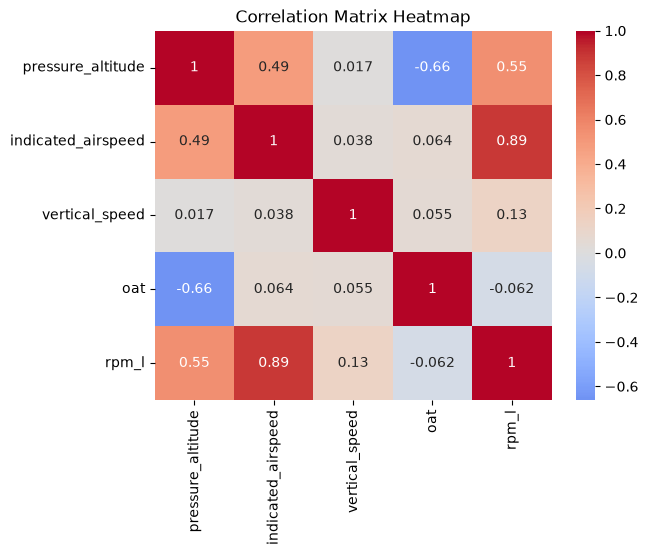

In [13]:
LOG.info("---------Visualize Correlation Matrix as a Heatmap---------------")

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
)
plt.title("Correlation Matrix Heatmap")
plt.show()

CUSTOM: Update these notes after reviewing your heatmap output.

Interpretation:

 - Values close to 1 (dark red) = strong positive correlation
 - Values close to -1 (dark blue) = strong negative correlation
 - Values close to 0 (white) = little or no linear relationship

Review the heatmap to determine whether pressure_altitude and indicated_airspeed show a meaningful correlation.

## Section 8. Make Plots

A scatter plot shows the relationship between two numeric variables (altitude vs airspeed).
A box plot shows the distribution of airspeed across altitude bands.

2026-06-20 16:42:36 | INFO | P06-DYNON | ---- Creating Scatter Plot to see Relationships ------
2026-06-20 16:42:36 | INFO | P06-DYNON | ----   Use clean dataframe ---------------------------
2026-06-20 16:42:36 | INFO | P06-DYNON | ----   Set x to Pressure Altitude (ft) -----------------------
2026-06-20 16:42:36 | INFO | P06-DYNON | ----   Set y to Indicated Airspeed (knots) --------------------------
2026-06-20 16:42:36 | INFO | P06-DYNON | ----   Set the hue (color mapping) to the group column --


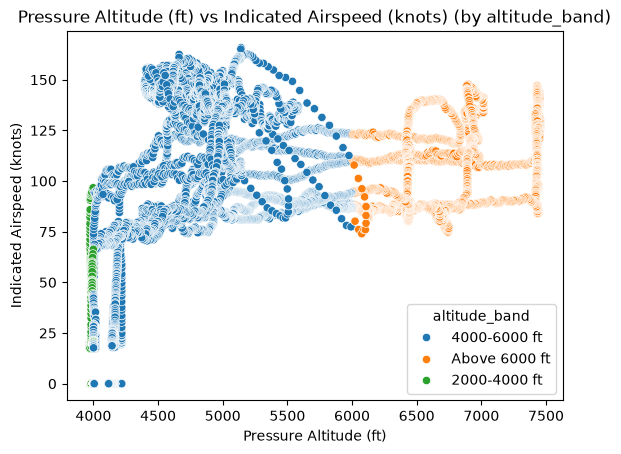

In [14]:
LOG.info("---- Creating Scatter Plot to see Relationships ------")
LOG.info("----   Use clean dataframe ---------------------------")
LOG.info(f"----   Set x to {SCATTER_X_LABEL} -----------------------")
LOG.info(f"----   Set y to {SCATTER_Y_LABEL} --------------------------")
LOG.info("----   Set the hue (color mapping) to the group column --")

scatter_plt: Axes = sns.scatterplot(
    data=df_clean,
    x=SCATTER_X_COL,
    y=SCATTER_Y_COL,
    hue=GROUP_COL,
)

scatter_plt.set_xlabel(SCATTER_X_LABEL)
scatter_plt.set_ylabel(SCATTER_Y_LABEL)
scatter_plt.set_title(f"{SCATTER_X_LABEL} vs {SCATTER_Y_LABEL} (by {GROUP_COL})")

plt.show()

2026-06-20 16:42:37 | INFO | P06-DYNON | ------- Creating another chart -------
2026-06-20 16:42:37 | INFO | P06-DYNON | ------ Creating Box Plot to see Distribution: ---------
2026-06-20 16:42:37 | INFO | P06-DYNON | ------   Use clean dataframe --------------------------
2026-06-20 16:42:37 | INFO | P06-DYNON | ------   Set x to the group column --------------------
2026-06-20 16:42:37 | INFO | P06-DYNON | ------   Set y to Indicated Airspeed (knots) ----------------------


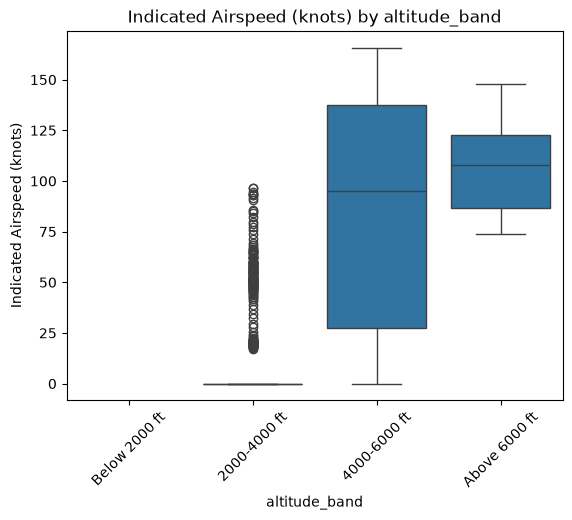

In [15]:
LOG.info("------- Creating another chart -------")
plt.figure()

LOG.info("------ Creating Box Plot to see Distribution: ---------")
LOG.info("------   Use clean dataframe --------------------------")
LOG.info("------   Set x to the group column --------------------")
LOG.info(f"------   Set y to {BOX_Y_LABEL} ----------------------")

box_plt: Axes = sns.boxplot(
    data=df_clean,
    x=GROUP_COL,
    y=BOX_Y_COL,
    order=["Below 2000 ft", "2000-4000 ft", "4000-6000 ft", "Above 6000 ft"],
)
box_plt.set_xlabel(GROUP_COL)
box_plt.set_ylabel(BOX_Y_LABEL)
box_plt.set_title(f"{BOX_Y_LABEL} by {GROUP_COL}")

box_plt.tick_params(axis="x", labelrotation=45)

plt.show()

## Section 9. Summary and Next Steps

A brief summary of findings and suggested next steps.

In [16]:
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset: {DATASET_NAME}")

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Clean rows:    {df_clean.shape[0]}")

unique_groups_array: np.ndarray = df_clean[GROUP_COL].unique()
sorted_groups: list[str] = sorted(unique_groups_array)

LOG.info(f"Groups found in {GROUP_COL}: {sorted_groups}")

LOG.info("======================")
LOG.info("Review the results.")
LOG.info("Determine the strongest correlations.")
LOG.info("======================")

LOG.info("EDA workflow complete")
LOG.info("========================")
LOG.info("Executed successfully!")
LOG.info("========================")

2026-06-20 16:42:37 | INFO | P06-DYNON | ========================
2026-06-20 16:42:37 | INFO | P06-DYNON | SUMMARY
2026-06-20 16:42:37 | INFO | P06-DYNON | ========================
2026-06-20 16:42:37 | INFO | P06-DYNON | Dataset: dynon_data
2026-06-20 16:42:37 | INFO | P06-DYNON | Original rows: 14131
2026-06-20 16:42:37 | INFO | P06-DYNON | Clean rows:    14122
2026-06-20 16:42:37 | INFO | P06-DYNON | Groups found in altitude_band: ['2000-4000 ft', '4000-6000 ft', 'Above 6000 ft']
2026-06-20 16:42:37 | INFO | P06-DYNON | ======================
2026-06-20 16:42:37 | INFO | P06-DYNON | Review the results.
2026-06-20 16:42:37 | INFO | P06-DYNON | Determine the strongest correlations.
2026-06-20 16:42:37 | INFO | P06-DYNON | ======================
2026-06-20 16:42:37 | INFO | P06-DYNON | EDA workflow complete
2026-06-20 16:42:37 | INFO | P06-DYNON | ========================
2026-06-20 16:42:37 | INFO | P06-DYNON | Executed successfully!
2026-06-20 16:42:37 | INFO | P06-DYNON | ==========